In [1]:
from stopping_analysis import StoppingPowerAnalysis

import numpy as np
import matplotlib.pyplot as plt

In [43]:
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/small_unitcell/"
data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/larger_unitcell/"

In [44]:
analysis = StoppingPowerAnalysis(data_directory)

{
    "40 keV": [
        "Al_stopping_40k_step10.gpw",
        "Al_stopping_40k_step20.gpw",
        "Al_stopping_40k_step30.gpw",
        "Al_stopping_40k_step40.gpw",
        "Al_stopping_40k_step50.gpw",
        "Al_stopping_40k_step60.gpw",
        "Al_stopping_40k_step70.gpw",
        "Al_stopping_40k_step80.gpw",
        "Al_stopping_40k_step90.gpw"
    ]
}


In [ ]:
# MONKEY PATCHING PLOT KINETIC ENERGIES FUNCTION JUST TO TEST IT WITHOUT LOADING IN GPAW FILES EVERY TIME

def new_plot_kinetic_energies(self):
    n_subplots = len(self.kinetic_energies.keys())
    fig, axs = plt.subplots(n_subplots, figsize=(10, 5*n_subplots), sharex=True)
    # so that is works for the =1 case
    if n_subplots == 1: axs = [axs]

    # TODO: add fitting to extract stopping powers - might be hard to account for different sizes of supercells

    axs[0].set_title("Fitting KE to extract stopping powers")

    axs[-1].set_xlabel(r"projectile position [$\AA$]")
    _ = [ax.set_ylabel("kinetic energy [keV]") for ax in axs]
    

    for i in range(n_subplots):
        energy, kinetic_energies = list(self.kinetic_energies.items())[i]
        kinetic_energies = np.array(kinetic_energies) * 1e-3 # convert from eV to keV
        _, projectile_positions = list(
            self.projectile_positions.items())[i]

        ##################################
        # PERFORM SLIDING WINDOW FITTING #
        #     and get stopping power
        ##################################

        # TODO: should be able to calculat the minimum window size from the size of the unit cell and from the distance travelled per timestep
        fit, cov, x_window, y_window = sliding_fit(projectile_positions, kinetic_energies, 4, 5)
        stopping_power = -fit[0]
        stopping_power_uncertainty = np.sqrt(cov[0][0])


        axs[i].plot(projectile_positions, kinetic_energies, "x")
        axs[i].plot(x_window, y_window, "x", color="red")
        axs[i].plot(x_window, np.poly1d(fit)(x_window), color="red", label=rf"$S_e$ = {1e3*stopping_power:.1f} $\pm$ {1e3*stopping_power_uncertainty:.1f} [eV/$\AA$]")





    print(projectile_positions)
    print(kinetic_energies)

    _ = [ax.legend() for ax in axs]
    plt.show()



StoppingPowerAnalysis.plot_kinetic_energies = new_plot_kinetic_energies


[np.float64(5.651836571859784), np.float64(9.303695505392518), np.float64(12.955597336957647), np.float64(16.60664156800656), np.float64(20.25469746784795), np.float64(23.90018147297284), np.float64(27.54543381441009), np.float64(31.190594547321837), np.float64(34.8354565434082)]
[40.00027564 40.00103935 40.00156827 39.9522142  39.88468123 39.85372133
 39.85703853 39.84983422 39.84661669]


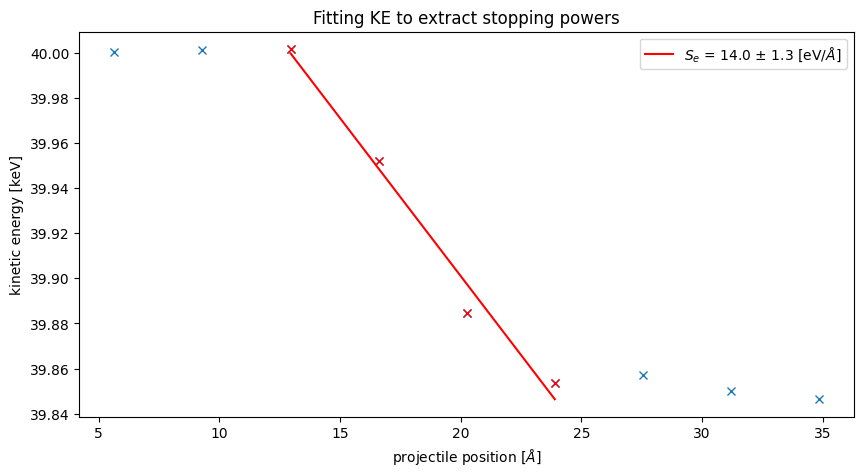

In [85]:
analysis.plot_kinetic_energies()

In [68]:
def calculate_r2(x, y, y_fit):
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else -np.inf
    return r2


def sliding_fit(x,y, min_window_size, max_window_size = None):
    if max_window_size == None:
        max_window_size = len(x)


    best_r2 = -np.inf
    best_start = 0
    best_fit = None
    best_cov = None
    best_x = None
    best_y = None


    for window_size in range(min_window_size, len(x)):
        for i in range(len(x) - window_size):
            x_window = x[i : i+window_size]
            y_window = y[i : i+window_size]

            fit, cov = np.polyfit(x_window, y_window, 1, cov=True)
            pfit = np.poly1d(fit)
            y_fit = pfit(x_window)

            r2 = calculate_r2(x_window, y_window, y_fit)


            if r2 > best_r2:
                best_r2 = r2
                best_start = i
                best_fit = fit
                best_cov = cov
                best_x = x_window
                best_y = y_window

    return best_fit, best_cov, best_x, best_y
